# Defense Wins Championships: Defensive Performance and Winning in FBS College Football
Harrison Barnes 
## Research Question
**Which defensive performance metrics are most strongly associated with winning in FBS college football during the NIL era?**

This project uses data from the College Football Data API to examine the relationship between defensive performance and winning. Particular attention will be given to disruptive defensive plays, such as sacks, tackles for loss, interceptions, and fumble recoveries.

In [144]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

In [145]:
load_dotenv("../.env", override=True)

api_key = os.getenv("CFBD_API_KEY")

if api_key:
    print("CFBD API key loaded successfully!")
else:
    print("CFBD API key was not found.")

CFBD API key loaded successfully!


In [146]:
headers = {
    "Authorization": f"Bearer {api_key}"
}

url = "https://api.collegefootballdata.com/games/teams"

params = {
    "year": 2025,
    "week": 1
}

response = requests.get(url, headers=headers, params=params)

print("Status code:", response.status_code)

response.raise_for_status()

data = response.json()

print("Number of games returned:", len(data))

Status code: 200
Number of games returned: 191


In [147]:
params = {
    "year": 2025,
    "classification": "fbs"
}

## DEFENSIVE STATISTICS ##

In [148]:
team_data = []

for game in data:

    if len(game["teams"]) == 2:

        for i in range(2):

            team = game["teams"][i]

            if i == 0:
                opponent = game["teams"][1]
            else:
                opponent = game["teams"][0]

            # Start defensive stats at 0
            interceptions = 0
            fumbles_recovered = 0
            total_yards_allowed = 0
            rushing_yards_allowed = 0
            passing_yards_allowed = 0

            # Get defensive stats for the team
            for stat in team["stats"]:

                if stat["category"] == "interceptions":
                    interceptions = int(stat["stat"])

                if stat["category"] == "fumblesRecovered":
                    fumbles_recovered = int(stat["stat"])

            # Opponent offensive yards = yards allowed by our team
            for stat in opponent["stats"]:

                if stat["category"] == "totalYards":
                    total_yards_allowed = int(stat["stat"])

                if stat["category"] == "rushingYards":
                    rushing_yards_allowed = int(stat["stat"])

                if stat["category"] == "netPassingYards":
                    passing_yards_allowed = int(stat["stat"])

            # Determine if the team won
            if team["points"] > opponent["points"]:
                win = 1
            else:
                win = 0

            # Create one row for the team
            row = {
                "team": team["team"],
                "team_conference": team["conference"],
                "opponent": opponent["team"],
                "opponent_conference": opponent["conference"],
                "points_allowed": opponent["points"],
                "total_yards_allowed": total_yards_allowed,
                "rushing_yards_allowed": rushing_yards_allowed,
                "passing_yards_allowed": passing_yards_allowed,
                "interceptions": interceptions,
                "fumbles_recovered": fumbles_recovered,
                "disruptive_plays": interceptions + fumbles_recovered,
                "win": win
            }

            team_data.append(row)

In [149]:
df = pd.DataFrame(team_data)

df.head()

,team,team_conference,opponent,opponent_conference,points_allowed,total_yards_allowed,rushing_yards_allowed,passing_yards_allowed,interceptions,fumbles_recovered,disruptive_plays,win
0,Drake,Pioneer,Upper Iowa,Great Lakes,7,219,18,201,1,1,2,1
1,Upper Iowa,Great Lakes,Drake,Pioneer,41,479,201,278,2,0,2,0
2,Southern Illinois,MVFC,Thomas More,Great Midwest Athletic,3,191,60,131,0,3,3,1
3,Thomas More,Great Midwest Athletic,Southern Illinois,MVFC,49,386,148,238,2,0,2,0
4,UT Rio Grande Valley,Southland,Sul Ross State,Lone Star,0,74,33,41,0,1,1,1


In [150]:
df.shape

(382, 12)

In [151]:
df["win"].value_counts()

win
1    191
0    191
Name: count, dtype: int64

In [152]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 382
Columns: 12


In [153]:
df.isnull().sum()

team                     0
team_conference          6
opponent                 0
opponent_conference      6
points_allowed           0
total_yards_allowed      0
rushing_yards_allowed    0
passing_yards_allowed    0
interceptions            0
fumbles_recovered        0
disruptive_plays         0
win                      0
dtype: int64

** NO MISSING VALUES!! **

In [154]:
df.describe()

,points_allowed,total_yards_allowed,rushing_yards_allowed,passing_yards_allowed,interceptions,fumbles_recovered,disruptive_plays,win
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,24.973822,356.248691,147.659686,208.623037,0.691099,0.581152,1.272251,0.500000
std,15.965328,122.952089,84.865151,86.722257,0.927206,0.778626,1.172392,0.500656
min,0.000000,53.000000,-32.000000,22.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,269.250000,87.000000,143.250000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,353.000000,133.000000,201.500000,0.000000,0.000000,1.000000,0.500000
75%,35.000000,436.250000,194.000000,262.750000,1.000000,1.000000,2.000000,1.000000
max,73.000000,695.000000,468.000000,491.000000,6.000000,4.000000,6.000000,1.000000


In [155]:
df["team"].nunique()

269

In [156]:
df["team"].unique()

<StringArray>
[               'Drake',           'Upper Iowa',    'Southern Illinois',
          'Thomas More', 'UT Rio Grande Valley',       'Sul Ross State',
     'Washington State',                'Idaho',       'Morehead State',
                'Allen',
 ...
              'McNeese',              'Montana',      'Tennessee State',
   'North Carolina A&T', 'Webber International',              'Stetson',
      'Cumberland (TN)',       'Tennessee Tech',   'Virginia Lynchburg',
           'Valparaiso']
Length: 269, dtype: str

## ELIMINATE NON FBS TEAMS FROM DATA SET ##

In [157]:
fbs_conferences = [
    "ACC",
    "American Athletic",
    "Big 12",
    "Big Ten",
    "Conference USA",
    "FBS Independents",
    "Mid-American",
    "Mountain West",
    "Pac-12",
    "SEC",
    "Sun Belt"
]

In [158]:
df_fbs = df[
    df["team_conference"].isin(fbs_conferences) &
    df["opponent_conference"].isin(fbs_conferences)
]

df_fbs.head()

,team,team_conference,opponent,opponent_conference,points_allowed,total_yards_allowed,rushing_yards_allowed,passing_yards_allowed,interceptions,fumbles_recovered,disruptive_plays,win
12,Iowa State,Big 12,Kansas State,Big 12,21,383,110,273,0,2,2,1
13,Kansas State,Big 12,Iowa State,Big 12,24,313,130,183,0,2,2,0
16,Auburn,SEC,Baylor,Big 12,24,483,64,419,0,0,0,1
17,Baylor,Big 12,Auburn,SEC,38,415,307,108,0,0,0,0
22,Oregon,Big Ten,Texas Tech,Big 12,0,215,78,137,1,3,4,1


In [159]:
df_fbs = df_fbs.drop_duplicates().copy()

print("Rows after removing duplicates:", df_fbs.shape)
print("Unique teams:", df_fbs["team"].nunique())
print("\nWin counts:")
print(df_fbs["win"].value_counts())

Rows after removing duplicates: (188, 12)
Unique teams: 120

Win counts:
win
1    94
0    94
Name: count, dtype: int64


In [160]:
print("Before filtering:", df.shape)
print("After filtering:", df_fbs.shape)
print("Unique FBS teams:", df_fbs["team"].nunique())

Before filtering: (382, 12)
After filtering: (188, 12)
Unique FBS teams: 120


In [161]:
df["team_conference"].unique()

<StringArray>
[               'Pioneer',            'Great Lakes',                   'MVFC',
 'Great Midwest Athletic',              'Southland',              'Lone Star',
                 'Pac-12',                'Big Sky',                   'SIAC',
          'OVC-Big South',                 'Big 12',                    'SEC',
                   'SWAC',                'Big Ten',                    'NEC',
          'Mountain West',                    'ACC',                    'UAC',
       'FCS Independents',               'Southern',      'American Athletic',
         'Conference USA',               'Sun Belt',                      nan,
       'Coastal Athletic',                   'MEAC',           'Mid-American',
                'Patriot',       'FBS Independents',         'Rocky Mountain']
Length: 30, dtype: str

In [162]:
df_fbs["team_conference"].value_counts()

team_conference
Big Ten              31
ACC                  26
SEC                  25
Mountain West        19
Sun Belt             19
Big 12               18
American Athletic    17
Mid-American         15
Conference USA       14
Pac-12                2
FBS Independents      2
Name: count, dtype: int64

## Visualization 1: Points Allowed in Wins vs. Losses ##

This visualization compares the number of points allowed by a team depending on whether the team won or lost the game.

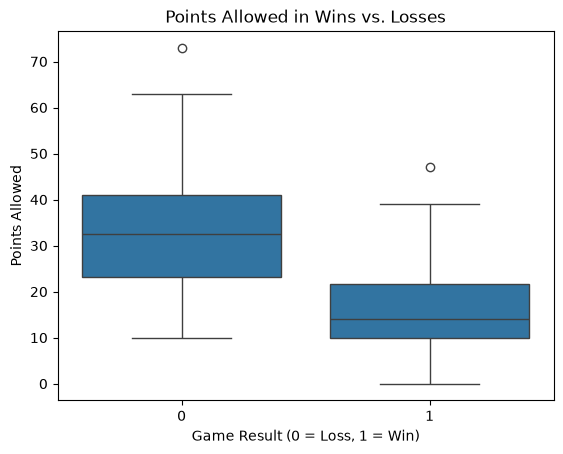

In [163]:
sns.boxplot(data=df_fbs, x="win", y="points_allowed")

plt.title("Points Allowed in Wins vs. Losses")
plt.xlabel("Game Result (0 = Loss, 1 = Win)")
plt.ylabel("Points Allowed")

plt.show()

### Interpretation

The boxplot shows a clear relationship between points allowed and winning. Teams that won generally allowed fewer points than teams that lost. Any sports fan knows that this finding is expected but the difference provided by the data was staggering. The median points allowed in wins was approximately 14 points, compared with approximately 32 points in losses. This suggests that limiting an opponent's scoring is strongly associated with winning in FBS college football.

## Visualization 2: Total Yards Allowed in Wins vs. Losses

This visualization compares the total yards allowed by teams in games they won versus games they lost.

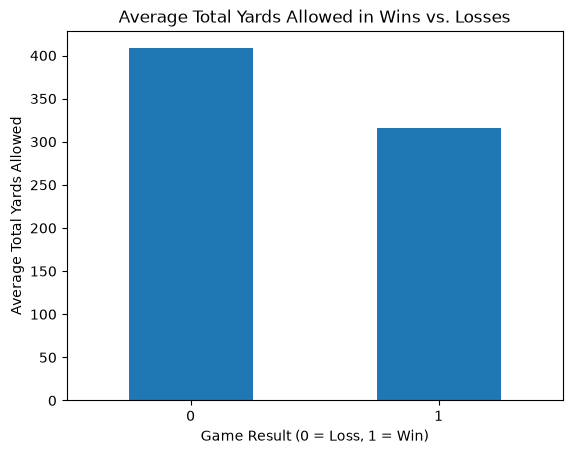

In [164]:
avg_yards = df_fbs.groupby("win")["total_yards_allowed"].mean()

avg_yards.plot(kind="bar")

plt.title("Average Total Yards Allowed in Wins vs. Losses")
plt.xlabel("Game Result (0 = Loss, 1 = Win)")
plt.ylabel("Average Total Yards Allowed")
plt.xticks(rotation=0)

plt.show()

### Interpretation

The bar chart shows that teams that won allowed fewer total yards on average than teams that lost. Losing teams allowed approximately 410 yards, while winning teams allowed approximately 315 yards. This difference suggests that limiting an opponent's total offensive production is associated with a greater likelihood of winning.

## Visualization 3: Rushing Yards Allowed and Win Percentage

This visualization examines whether teams that stop the run have a higher percentage of wins.

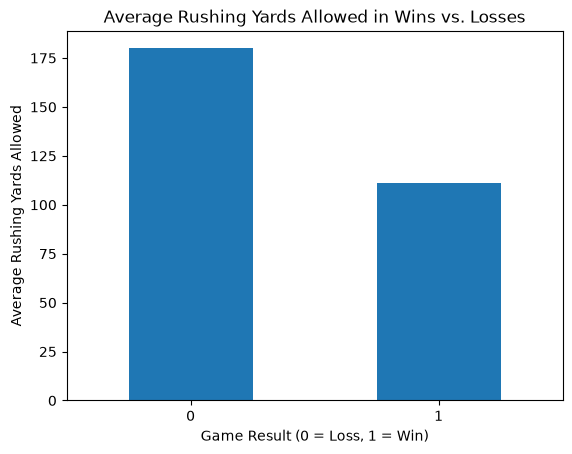

In [165]:
avg_rushing = df_fbs.groupby("win")["rushing_yards_allowed"].mean()

avg_rushing.plot(kind="bar")

plt.title("Average Rushing Yards Allowed in Wins vs. Losses")
plt.xlabel("Game Result (0 = Loss, 1 = Win)")
plt.ylabel("Average Rushing Yards Allowed")
plt.xticks(rotation=0)

plt.show()

Teams that won games allowed considerably fewer rushing yards on average than teams that lost. Winning teams allowed approximately 110 rushing yards, compared with approximately 180 rushing yards for losing teams. This suggests that limiting an opponent's rushing offense is associated with a greater likelihood of winning.

## Visualization 4: Disruptive Defensive Plays and Win Percentage

This visualization examines whether teams that create more disruptive defensive plays have a higher percentage of wins.

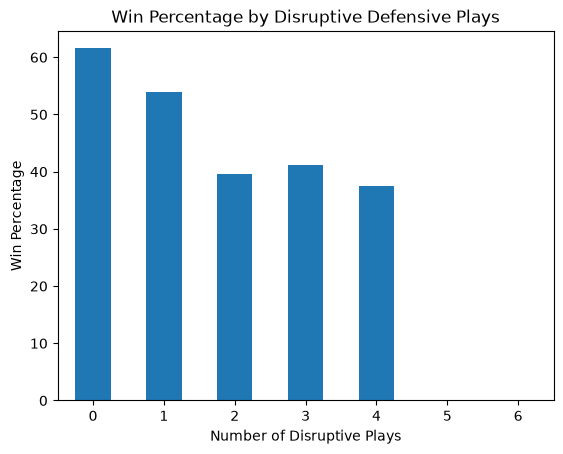

In [166]:
win_by_disruptive = df_fbs.groupby("disruptive_plays")["win"].mean() * 100

win_by_disruptive.plot(kind="bar")

plt.title("Win Percentage by Disruptive Defensive Plays")
plt.xlabel("Number of Disruptive Plays")
plt.ylabel("Win Percentage")
plt.xticks(rotation=0)

plt.show()

This graph examines the relationship between disruptive plays and win percentage. According to the graph there is a negative relationship between these two variables as number of disruptive plays increases win percentage decreases. This of course is the opposite of the expected relationship and I believe this is due to an issue with the collection or recording of the disruptive plays variable. The data is collected from the perspective of the offense so the issue could be the disruptive plays could be being attributed to the wrong team. There could also be a coding issue with the creation of the variable. 

## Statistical Analysis

In [167]:
defensive_summary = df_fbs.groupby("win")[
    ["points_allowed", "total_yards_allowed",
     "rushing_yards_allowed", "passing_yards_allowed"]
].mean()

defensive_summary

,points_allowed,total_yards_allowed,rushing_yards_allowed,passing_yards_allowed
win,,,,
0,32.202128,408.127660,179.861702,228.287234
1,15.914894,315.585106,110.925532,204.659574


In [168]:
loss_avg = df_fbs[df_fbs["win"] == 0][
    ["points_allowed", "total_yards_allowed",
     "rushing_yards_allowed", "passing_yards_allowed"]
].mean()

win_avg = df_fbs[df_fbs["win"] == 1][
    ["points_allowed", "total_yards_allowed",
     "rushing_yards_allowed", "passing_yards_allowed"]
].mean()

difference = loss_avg - win_avg

difference

points_allowed           16.287234
total_yards_allowed      92.542553
rushing_yards_allowed    68.936170
passing_yards_allowed    23.627660
dtype: float64

### Significance Testing

In [169]:
variables = [
    "points_allowed",
    "total_yards_allowed",
    "rushing_yards_allowed",
    "passing_yards_allowed"
]

for variable in variables:
    loss_mean = df_fbs[df_fbs["win"] == 0][variable].mean()
    win_mean = df_fbs[df_fbs["win"] == 1][variable].mean()

    difference = loss_mean - win_mean
    percent_lower = (difference / loss_mean) * 100

    print(variable)
    print("Loss average:", round(loss_mean, 2))
    print("Win average:", round(win_mean, 2))
    print("Difference:", round(difference, 2))
    print("Percent lower in wins:", round(percent_lower, 2), "%")
    print()

points_allowed
Loss average: 32.2
Win average: 15.91
Difference: 16.29
Percent lower in wins: 50.58 %

total_yards_allowed
Loss average: 408.13
Win average: 315.59
Difference: 92.54
Percent lower in wins: 22.67 %

rushing_yards_allowed
Loss average: 179.86
Win average: 110.93
Difference: 68.94
Percent lower in wins: 38.33 %

passing_yards_allowed
Loss average: 228.29
Win average: 204.66
Difference: 23.63
Percent lower in wins: 10.35 %



## Limitations, Ethics, and Reflection

This analysis has several limitations that should be considered when interpreting the results. First, the data only represents games available through the College Football Data API for the selected season and does not capture every factor that contributes to winning. Variables such as offensive performance, strength of schedule, injuries, coaching decisions, field position, home-field advantage, and special teams performance are not included in this analysis.

The defensive measures used in this project also provide only a partial picture of defensive quality. Points allowed, total yards allowed, rushing yards allowed, and passing yards allowed are useful measures, but they can be influenced by factors outside of the defense itself. For example, an offense that frequently turns the ball over may give the opposing team shorter fields and make the defense appear less effective.

The NIL era also adds important context. Programs now operate in an environment where NIL opportunities, the transfer portal, and other resources may influence the ability to recruit and retain players. However, this dataset does not include NIL spending, player compensation, transfer activity, or roster value. Therefore, this analysis cannot determine whether NIL investment directly improves defensive performance.

If more data were available, a future version of this project could combine defensive statistics with recruiting rankings, transfer portal activity, team spending or NIL-related measures, and strength of schedule. This would allow for a more complete investigation of how roster-building resources may relate to defensive performance and winning.

## Conclusion

This analysis examined the relationship between defensive performance and winning 
in FBS college football. The results show a clear association between stronger 
defensive performance and winning games.

Winning teams allowed an average of 15.91 points per game compared with 32.20 
points in losses, a difference of approximately 50.58%. Winning teams also allowed 
22.67% fewer total yards and 38.33% fewer rushing yards. Passing yards showed a 
smaller difference, with winning teams allowing approximately 10.35% fewer passing 
yards.

The visualizations support these findings by showing that teams generally allowed 
fewer points, total yards, and rushing yards in games they won compared with games 
they lost.

Overall, the results suggest that defensive performance is strongly associated 
with winning in FBS college football. Of the defensive measures examined, points 
allowed showed the largest percentage difference between wins and losses, while 
rushing defense also showed a substantial difference. These findings suggest that 
limiting scoring and controlling the opponent's rushing offense may be particularly 
important indicators of winning.

Because this analysis is observational, the results demonstrate an association 
between defensive performance and winning rather than proving that stronger 
defensive performance directly causes teams to win. But the results definitely support
adage Defense Wins Championships.